In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('weight-height.csv')

In [3]:
df.head(5)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


<AxesSubplot:xlabel='Height', ylabel='Count'>

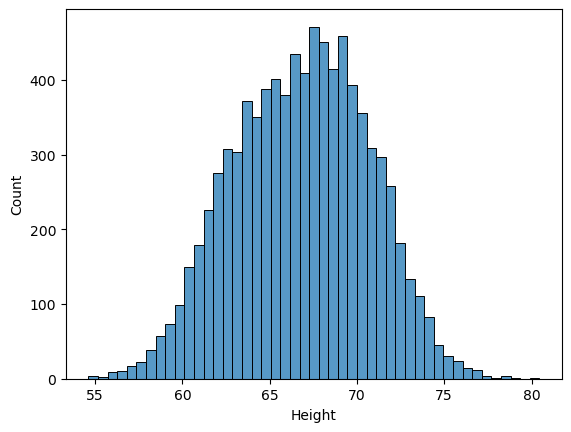

In [4]:
sns.histplot(df['Height'])

<AxesSubplot:xlabel='Height', ylabel='Count'>

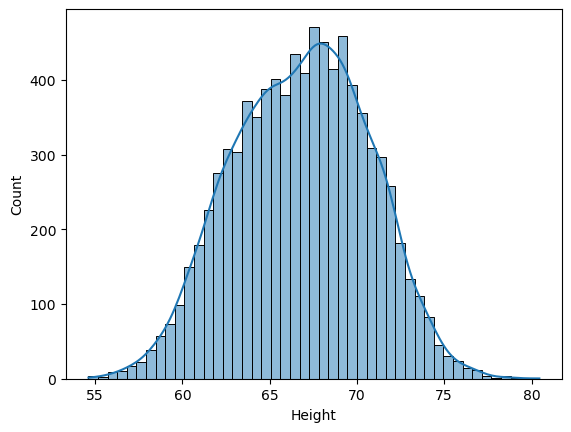

In [5]:
sns.histplot(df['Height'], kde=True)

<AxesSubplot:xlabel='Weight', ylabel='Count'>

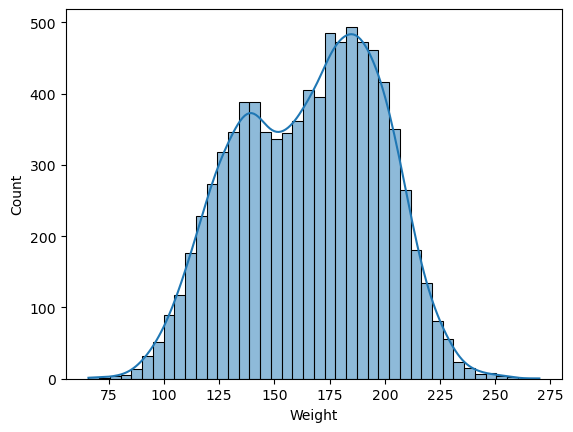

In [6]:
sns.histplot(df['Weight'], kde=True)

# Descriptive Stats

In [7]:
df.describe()

,Height,Weight
count,8555.000000,8555.000000
mean,66.809925,165.632735
std,3.851454,32.043922
min,54.616858,65.780000
25%,63.957684,139.876803
50%,66.985923,168.521567
75%,69.604427,190.666305
max,80.450000,269.989698


In [8]:
df.Height.mean()

66.80992512908925

In [9]:
df.Height.median()

66.98592338

In [10]:
df.Height.mode() #categorical

0       54.616858
1       54.873728
2       55.148557
3       55.336492
4       55.668202
          ...    
8550    78.462053
8551    78.528210
8552    78.621374
8553    78.998742
8554    80.450000
Name: Height, Length: 8555, dtype: float64

In [11]:
df.Height.std()

3.8514544315772765

In [12]:
df.Height.var()

14.833701238516243

In [13]:
df2 = df.copy()
df3 = df.copy()
df4 = df.copy()

# Z Scores

In [14]:
df['zscores'] = (df['Height'] - df['Height'].mean()) / df['Height'].std()

In [15]:
df.head()

,Gender,Height,Weight,zscores
0,Male,73.847017,241.893563,1.827126
1,Male,68.781904,162.310473,0.512009
2,Male,74.110105,212.740856,1.895435
3,Male,71.730978,220.042470,1.277713
4,Male,69.881796,206.349801,0.797587


In [16]:
df.zscores.max()

3.5415386870680865

In [17]:
df.zscores.min()

-3.1658344959558185

<AxesSubplot:xlabel='zscores', ylabel='Count'>

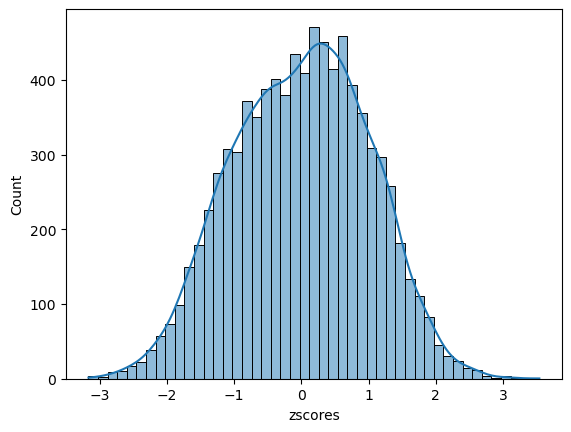

In [18]:
sns.histplot(df['zscores'], kde=True)

<AxesSubplot:xlabel='Height', ylabel='Count'>

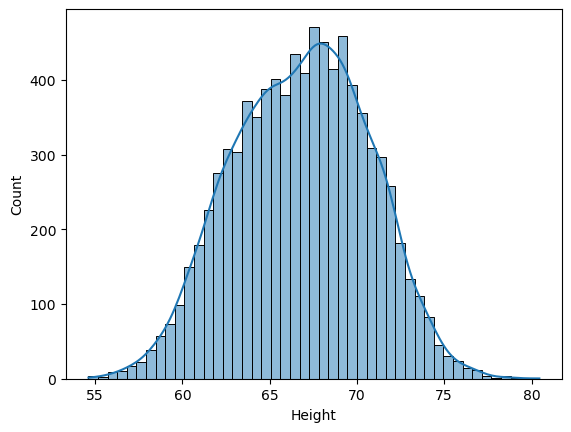

In [19]:
sns.histplot(df['Height'], kde=True)

# Standard Scaler

In [20]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

In [21]:
df['std_scaler'] = std.fit_transform(df[['Height']])
df.head()

,Gender,Height,Weight,zscores,std_scaler
0,Male,73.847017,241.893563,1.827126,1.827233
1,Male,68.781904,162.310473,0.512009,0.512039
2,Male,74.110105,212.740856,1.895435,1.895545
3,Male,71.730978,220.042470,1.277713,1.277788
4,Male,69.881796,206.349801,0.797587,0.797634


<AxesSubplot:xlabel='std_scaler', ylabel='Count'>

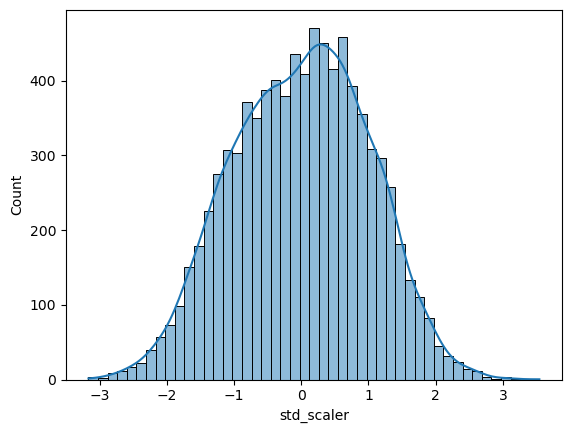

In [22]:
sns.histplot(df['std_scaler'], kde=True)

In [23]:
df.zscores.max()

3.5415386870680865

In [24]:
df.zscores.min()

-3.1658344959558185

In [25]:
df.zscores.mean() + 1 # mean is 0

1.0000000000000453

In [26]:
df.zscores.std() # std is 1

0.9999999999999981

# Remove outlier

In [27]:
max_z = df.zscores.max() 
min_z = df.zscores.min() 

In [28]:
min_z

-3.1658344959558185

In [29]:
max_z

3.5415386870680865

In [30]:
df[(df['zscores'] > 3)]

,Gender,Height,Weight,zscores,std_scaler
1317,Male,78.462053,227.342565,3.025384,3.025561
2014,Male,78.998742,269.989698,3.164731,3.164916
3285,Male,78.528210,253.889004,3.042561,3.042739
3757,Male,78.621374,245.733783,3.066750,3.066930
6328,Female,80.450000,178.020675,3.541539,3.541746


In [31]:
df[df['zscores']<-3]

,Gender,Height,Weight,zscores,std_scaler
6624,Female,54.616858,71.393749,-3.165834,-3.166020
7294,Female,54.873728,78.606670,-3.099140,-3.099321
7617,Female,55.148557,88.812412,-3.027783,-3.027960


In [32]:
after_remove_otliers = df[(df['zscores'] <= 3) & (df['zscores'] >= -3)]
after_remove_otliers

,Gender,Height,Weight,zscores,std_scaler
0,Male,73.847017,241.893563,1.827126,1.827233
1,Male,68.781904,162.310473,0.512009,0.512039
2,Male,74.110105,212.740856,1.895435,1.895545
3,Male,71.730978,220.042470,1.277713,1.277788
4,Male,69.881796,206.349801,0.797587,0.797634
...,...,...,...,...,...
8550,Female,60.483946,110.565497,-1.642491,-1.642587
8551,Female,63.423372,129.921671,-0.879292,-0.879344
8552,Female,65.584057,155.942671,-0.318287,-0.318306
8553,Female,67.429971,151.678405,0.160990,0.161000


In [33]:
df.shape

(8555, 5)

# who are the outliers?

In [34]:
df[(df['zscores'] >3) | (df['zscores']<-3)]

,Gender,Height,Weight,zscores,std_scaler
1317,Male,78.462053,227.342565,3.025384,3.025561
2014,Male,78.998742,269.989698,3.164731,3.164916
3285,Male,78.528210,253.889004,3.042561,3.042739
3757,Male,78.621374,245.733783,3.066750,3.066930
6328,Female,80.450000,178.020675,3.541539,3.541746
6624,Female,54.616858,71.393749,-3.165834,-3.166020
7294,Female,54.873728,78.606670,-3.099140,-3.099321
7617,Female,55.148557,88.812412,-3.027783,-3.027960


In [35]:
df.shape

(8555, 5)

<AxesSubplot:xlabel='Height', ylabel='Count'>

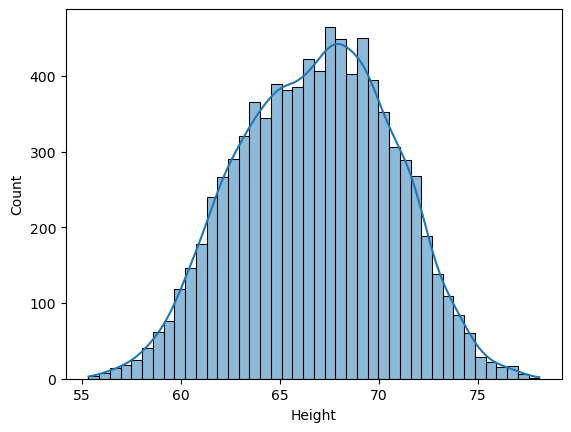

In [36]:
sns.histplot(after_remove_otliers['Height'], kde=True)

# STD

<AxesSubplot:xlabel='Height', ylabel='Count'>

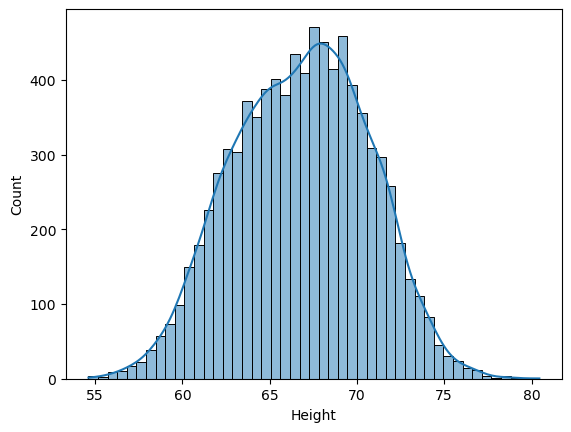

In [37]:
sns.histplot(df['Height'], kde=True)

In [38]:
mean = df2.Height.mean()
mean

66.80992512908925

In [39]:
std = df2.Height.std()
std

3.8514544315772765

In [40]:
sigma_3 = mean + (3*std)
sigma_3_neg = mean - (3*std)

In [41]:
sigma_3

78.36428842382108

In [42]:
sigma_3_neg

55.25556183435742

In [43]:
df2[df2['Height'] > sigma_3]

,Gender,Height,Weight
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989698
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6328,Female,80.450000,178.020675


In [44]:
df2[df2['Height'] < sigma_3_neg]

,Gender,Height,Weight
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
7617,Female,55.148557,88.812412


In [45]:
df[(df['zscores'] >3)]

,Gender,Height,Weight,zscores,std_scaler
1317,Male,78.462053,227.342565,3.025384,3.025561
2014,Male,78.998742,269.989698,3.164731,3.164916
3285,Male,78.528210,253.889004,3.042561,3.042739
3757,Male,78.621374,245.733783,3.066750,3.066930
6328,Female,80.450000,178.020675,3.541539,3.541746


In [46]:
df[(df['zscores'] >3) | (df['zscores']<-3)]

,Gender,Height,Weight,zscores,std_scaler
1317,Male,78.462053,227.342565,3.025384,3.025561
2014,Male,78.998742,269.989698,3.164731,3.164916
3285,Male,78.528210,253.889004,3.042561,3.042739
3757,Male,78.621374,245.733783,3.066750,3.066930
6328,Female,80.450000,178.020675,3.541539,3.541746
6624,Female,54.616858,71.393749,-3.165834,-3.166020
7294,Female,54.873728,78.606670,-3.099140,-3.099321
7617,Female,55.148557,88.812412,-3.027783,-3.027960


# who are the outliers?

In [47]:
df[(df['zscores'] >3) | (df['zscores']<-3)]

,Gender,Height,Weight,zscores,std_scaler
1317,Male,78.462053,227.342565,3.025384,3.025561
2014,Male,78.998742,269.989698,3.164731,3.164916
3285,Male,78.528210,253.889004,3.042561,3.042739
3757,Male,78.621374,245.733783,3.066750,3.066930
6328,Female,80.450000,178.020675,3.541539,3.541746
6624,Female,54.616858,71.393749,-3.165834,-3.166020
7294,Female,54.873728,78.606670,-3.099140,-3.099321
7617,Female,55.148557,88.812412,-3.027783,-3.027960


In [48]:
after_remove_df2 = df2[(df2['Height'] > sigma_3) | (df2['Height']<sigma_3_neg)] #only outliers
after_remove_df2

,Gender,Height,Weight
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989698
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6328,Female,80.450000,178.020675
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
7617,Female,55.148557,88.812412


In [49]:
df2.shape

(8555, 3)

In [50]:
df2[(df2.Height < sigma_3_neg) | (df2.Height > sigma_3) ]

,Gender,Height,Weight
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989698
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6328,Female,80.450000,178.020675
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
7617,Female,55.148557,88.812412


In [51]:
df[(df['zscores'] >3) | (df['zscores'] < -3)]

,Gender,Height,Weight,zscores,std_scaler
1317,Male,78.462053,227.342565,3.025384,3.025561
2014,Male,78.998742,269.989698,3.164731,3.164916
3285,Male,78.528210,253.889004,3.042561,3.042739
3757,Male,78.621374,245.733783,3.066750,3.066930
6328,Female,80.450000,178.020675,3.541539,3.541746
6624,Female,54.616858,71.393749,-3.165834,-3.166020
7294,Female,54.873728,78.606670,-3.099140,-3.099321
7617,Female,55.148557,88.812412,-3.027783,-3.027960


In [52]:
after_remove_df2 = df2[(df2['Height'] < sigma_3) & (df2['Height']>sigma_3_neg)] # no outliers 
after_remove_df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
8550,Female,60.483946,110.565497
8551,Female,63.423372,129.921671
8552,Female,65.584057,155.942671
8553,Female,67.429971,151.678405


# Boxplot

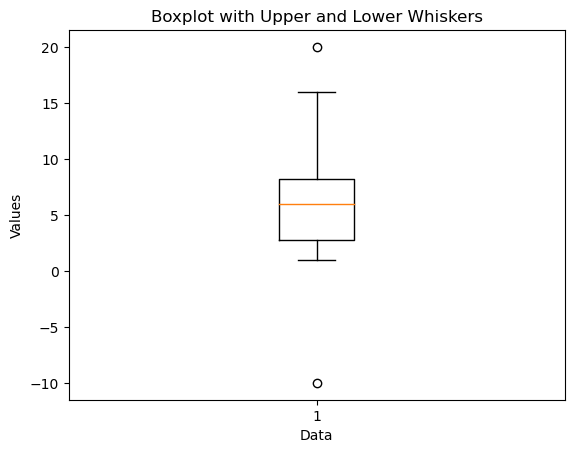

In [53]:
data = np.array([-10, 1,2,3,3,5,7,7,8,9,16,20])
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1

upper_whisker = q3 + 1.5 * iqr
lower_whisker = q1 - 1.5 * iqr

outliers = (data < lower_whisker) | (data > upper_whisker)

fig, ax = plt.subplots()
ax.boxplot(data)

ax.set_title('Boxplot with Upper and Lower Whiskers')
ax.set_xlabel('Data')
ax.set_ylabel('Values')
plt.show()


In [54]:
q1

2.75

In [55]:
q3

8.25

In [56]:
np.percentile(data, 50)

6.0

In [ ]:
fig, ax = plt.subplots()
ax.boxplot(df['Height'])

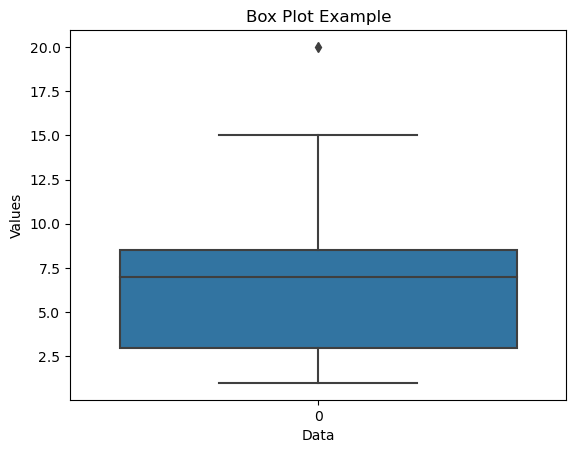

In [57]:
data = [1,2,3,3,5,7,7,8,9,15,20]

sns.boxplot(data=data)
plt.xlabel('Data')
plt.ylabel('Values')
plt.title('Box Plot Example')

plt.show()


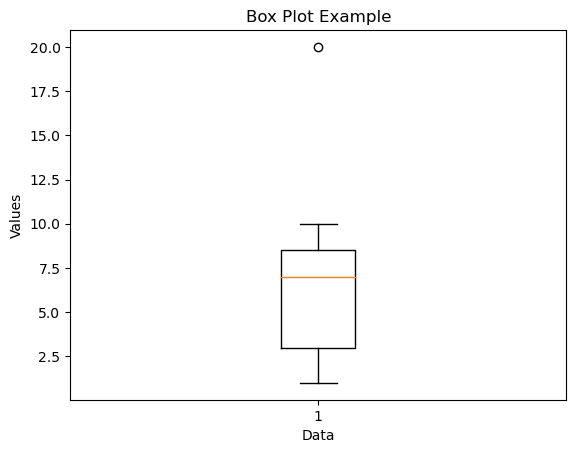

In [58]:
data = [1,2,3,3,5,7,7,8,9,10,20]

fig, ax = plt.subplots()
ax.boxplot(data)

ax.set_xlabel('Data')
ax.set_ylabel('Values')
ax.set_title('Box Plot Example')
plt.show()
